In [1]:
import os
import sys
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium import plugins
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import requests


print(f"  Folium version    : {folium.__version__}")
print(f"  GeoPandas version : {gpd.__version__}")



  Folium version    : 0.20.0
  GeoPandas version : 1.1.3


In [2]:
HORIZONS = [1, 3, 7]
TARGET   = "rainfall_mm"

FLOOD_THRESHOLDS = {"Watch": 50, "Warning": 80, "Danger": 120}

RISK_COLOURS = {
    "🟢 NORMAL":   "#2ECC71",
    "🟡 WATCH":    "#F1C40F",
    "🟠 WARNING":  "#E67E22",
    "🔴 DANGER":   "#E74C3C",
}

# Bangladesh bounding box (for map centering)
BD_LAT = 23.6850
BD_LON = 90.3563

# Division centres — one representative point per division
DIVISION_CENTRES = {
    "dhaka":      {"lat": 23.8103, "lon": 90.4125, "label": "Dhaka"},
    "chittagong": {"lat": 22.3475, "lon": 91.8123, "label": "Chittagong"},
    "sylhet":     {"lat": 24.8949, "lon": 91.8687, "label": "Sylhet"},
    "rajshahi":   {"lat": 24.3745, "lon": 88.6042, "label": "Rajshahi"},
    "khulna":     {"lat": 22.8456, "lon": 89.5403, "label": "Khulna"},
    "barisal":    {"lat": 22.7010, "lon": 90.3535, "label": "Barisal"},
    "rangpur":    {"lat": 25.7439, "lon": 89.2752, "label": "Rangpur"},
    "mymensingh": {"lat": 24.7471, "lon": 90.4203, "label": "Mymensingh"},
}

os.makedirs("../data/raw",       exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models",         exist_ok=True)

print(f"\n  Divisions: {list(DIVISION_CENTRES.keys())}")


  Divisions: ['dhaka', 'chittagong', 'sylhet', 'rajshahi', 'khulna', 'barisal', 'rangpur', 'mymensingh']


## Download Bangladesh GeoJSON

In [5]:
# Bangladesh district-level GeoJSON from GADM (free, open data)
# This has all 64 districts with polygon boundaries

import os, requests
import geopandas as gpd

GEOJSON_PATH = "../data/raw/bangladesh_districts.geojson"

# Ensure directory exists
os.makedirs(os.path.dirname(GEOJSON_PATH), exist_ok=True)

if os.path.exists(GEOJSON_PATH):
    print(f"✓ GeoJSON already exists at {GEOJSON_PATH}")
else:
    print("Downloading Bangladesh district boundaries...")
    url = (
        "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BGD_2.json"
    )
    try:
        resp = requests.get(url, timeout=120)  # increased timeout
        resp.raise_for_status()
        with open(GEOJSON_PATH, "wb") as f:
            f.write(resp.content)
        print(f"✓ Downloaded → {GEOJSON_PATH}")
    except Exception as e:
        print(f"⚠ Download failed: {e}")

# Load only if file now exists
if os.path.exists(GEOJSON_PATH):
    gdf = gpd.read_file(GEOJSON_PATH)
    print(f"\nGeoDataFrame shape : {gdf.shape}")
    print(f"Columns            : {list(gdf.columns)}")
    print(f"CRS                : {gdf.crs}")
    gdf.head(3)
else:
    print("⚠ File still missing — manual download required")
    print("  1. Visit: https://geodata.ucdavis.edu/gadm/gadm4.1/json/")
    print("  2. Download: gadm41_BGD_2.json")
    print(f"  3. Save as: {os.path.abspath(GEOJSON_PATH)}")

✓ GeoJSON already exists at ../data/raw/bangladesh_districts.geojson

GeoDataFrame shape : (64, 14)
Columns            : ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']
CRS                : EPSG:4326


## Inspect and clean district GeoJSON

In [6]:
# GADM uses 'NAME_1' for division, 'NAME_2' for district
# We need to map districts to their divisions for colour-coding

print("Unique divisions in GeoJSON (NAME_1):")
print(sorted(gdf["NAME_1"].unique()))

print("\nSample district names (NAME_2):")
print(sorted(gdf["NAME_2"].unique())[:20])

# Standardise division names to lowercase (to match our station keys)
NAME_MAP = {
    "Dhaka":        "dhaka",
    "Chattogram":   "chittagong",    # GADM uses 'Chattogram'
    "Chittagong":   "chittagong",
    "Sylhet":       "sylhet",
    "Rajshahi":     "rajshahi",
    "Khulna":       "khulna",
    "Barishal":     "barisal",       # GADM uses 'Barishal'
    "Barisal":      "barisal",
    "Rangpur":      "rangpur",
    "Mymensingh":   "mymensingh",
}

gdf["division_key"] = gdf["NAME_1"].map(NAME_MAP)

# Check for unmapped divisions
unmapped = gdf[gdf["division_key"].isna()]["NAME_1"].unique()
if len(unmapped) > 0:
    print(f"\n⚠ Unmapped divisions: {unmapped}")
    print("  Add these to NAME_MAP above")
else:
    print("\n✓ All divisions mapped successfully")

print(f"\nDistricts per division:")
print(gdf.groupby("division_key")["NAME_2"].count().to_string())

Unique divisions in GeoJSON (NAME_1):
['Barisal', 'Chittagong', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']

Sample district names (NAME_2):
['Bagerhat', 'Bandarban', 'Barguna', 'Barisal', 'Bhola', 'Bogra', 'Brahamanbaria', 'Chandpur', 'Chittagong', 'Chuadanga', 'Comilla', "Cox'SBazar", 'Dhaka', 'Dinajpur', 'Faridpur', 'Feni', 'Gaibandha', 'Gazipur', 'Gopalganj', 'Habiganj']

✓ All divisions mapped successfully

Districts per division:
division_key
barisal        6
chittagong    11
dhaka         13
khulna        10
mymensingh     4
rajshahi       8
rangpur        8
sylhet         4


## Load all station data and models

In [7]:
# Load cleaned data for all stations
all_data = {}
for station in DIVISION_CENTRES.keys():
    path = f"../data/processed/{station}_clean.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, index_col="date", parse_dates=True)
        if "station" in df.columns:
            df = df.drop(columns=["station"])
        all_data[station] = df
        print(f"  ✓ Loaded {station:12} — {len(df):,} rows")
    else:
        print(f"  ⚠ Missing: {path} — run notebook_01 first")

print(f"\n✓ Loaded {len(all_data)} stations")

# Load trained XGBoost models
xgb_models = {}
for h in HORIZONS:
    path = f"../models/xgb_dhaka_h{h}d.joblib"
    if os.path.exists(path):
        xgb_models[h] = joblib.load(path)
        print(f"  ✓ Loaded XGBoost H={h}d model")
    else:
        print(f"  ⚠ Missing: {path} — run notebook_03 first")

  ✓ Loaded dhaka        — 8,766 rows
  ✓ Loaded chittagong   — 8,766 rows
  ✓ Loaded sylhet       — 8,766 rows
  ✓ Loaded rajshahi     — 8,766 rows
  ✓ Loaded khulna       — 8,766 rows
  ✓ Loaded barisal      — 8,766 rows
  ✓ Loaded rangpur      — 8,766 rows
  ✓ Loaded mymensingh   — 8,766 rows

✓ Loaded 8 stations
  ✓ Loaded XGBoost H=1d model
  ✓ Loaded XGBoost H=3d model
  ✓ Loaded XGBoost H=7d model


## Feature engineering 

In [8]:
# Rebuild features for all stations so we can run inference
# This must match EXACTLY what was used during training

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df   = df.copy()
    rain = df[TARGET]

    for lag in [1, 2, 3, 5, 7, 10, 14, 21, 30]:
        df[f"rain_lag_{lag}d"] = rain.shift(lag)

    for window in [3, 7, 14, 30]:
        df[f"rain_roll_mean_{window}d"] = rain.shift(1).rolling(window).mean()
        df[f"rain_roll_std_{window}d"]  = rain.shift(1).rolling(window).std()
        df[f"rain_roll_max_{window}d"]  = rain.shift(1).rolling(window).max()

    monsoon_rain = rain.where(df.index.month.isin([6,7,8,9,10]), 0)
    df["monsoon_cumulative"] = monsoon_rain.groupby(
        df.index.year
    ).transform("cumsum")

    counter = 0
    days_list = []
    for v in (rain > 50).astype(int):
        counter = 0 if v else counter + 1
        days_list.append(counter)
    df["days_since_heavy_rain"] = days_list

    df["month"]          = df.index.month
    df["day_of_year"]    = df.index.dayofyear
    df["week_of_year"]   = df.index.isocalendar().week.astype(int)
    df["is_monsoon"]     = df["month"].isin([6,7,8,9,10]).astype(int)
    df["is_pre_monsoon"] = df["month"].isin([3,4,5]).astype(int)
    df["doy_sin"]        = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"]        = np.cos(2 * np.pi * df["day_of_year"] / 365)
    df["month_sin"]      = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"]      = np.cos(2 * np.pi * df["month"] / 12)

    for col in ["temp_c", "humidity_pct", "wind_speed_ms"]:
        if col in df.columns:
            df[f"{col}_lag1"]       = df[col].shift(1)
            df[f"{col}_lag3"]       = df[col].shift(3)
            df[f"{col}_roll7_mean"] = df[col].shift(1).rolling(7).mean()

    if "humidity_pct" in df.columns:
        df["humidity_x_monsoon"] = df["humidity_pct"] * df["is_monsoon"]

    df = df.dropna()
    return df


# Build features for every station
all_feat = {}
for station, df in all_data.items():
    all_feat[station] = build_features(df)
    print(f"  ✓ {station:12} — {all_feat[station].shape[1]} features")

feature_cols = [c for c in all_feat["dhaka"].columns if c != TARGET]
print(f"\n  Total features : {len(feature_cols)}")

  ✓ dhaka        — 46 features
  ✓ chittagong   — 46 features
  ✓ sylhet       — 46 features
  ✓ rajshahi     — 46 features
  ✓ khulna       — 46 features
  ✓ barisal      — 46 features
  ✓ rangpur      — 46 features
  ✓ mymensingh   — 46 features

  Total features : 45


## Generate forecasts for all divisions

In [9]:
def flood_risk_tier(mm):
    mm = float(mm)
    if mm >= FLOOD_THRESHOLDS["Danger"]:  return "🔴 DANGER"
    if mm >= FLOOD_THRESHOLDS["Warning"]: return "🟠 WARNING"
    if mm >= FLOOD_THRESHOLDS["Watch"]:   return "🟡 WATCH"
    return "🟢 NORMAL"

def risk_colour(tier):
    return RISK_COLOURS.get(tier, "#2ECC71")

# Run inference using the LAST row of each station's feature data
# In production this would use today's NASA POWER data
forecast_records = []

for station, feat_df in all_feat.items():
    latest = feat_df.iloc[[-1]]           # last available data point
    base_date = feat_df.index[-1]

    for h in HORIZONS:
        if h not in xgb_models:
            continue

        model   = xgb_models[h]
        X       = latest[feature_cols].values
        pred_mm = float(np.clip(model.predict(X)[0], 0, None))
        tier    = flood_risk_tier(pred_mm)

        forecast_records.append({
            "station":       station,
            "label":         DIVISION_CENTRES[station]["label"],
            "lat":           DIVISION_CENTRES[station]["lat"],
            "lon":           DIVISION_CENTRES[station]["lon"],
            "horizon_days":  h,
            "base_date":     base_date.date(),
            "forecast_date": (base_date + pd.DateOffset(days=h)).date(),
            "predicted_mm":  round(pred_mm, 1),
            "risk_tier":     tier,
            "colour":        risk_colour(tier),
        })

forecast_df = pd.DataFrame(forecast_records)
forecast_df.to_csv("../data/processed/division_forecasts.csv", index=False)

print("Forecast table — all divisions × all horizons:\n")
display(forecast_df.pivot_table(
    index="station",
    columns="horizon_days",
    values=["predicted_mm", "risk_tier"],
    aggfunc="first"
))
print(f"\n✓ Saved → ../data/processed/division_forecasts.csv")

Forecast table — all divisions × all horizons:



predicted_mm           risk_tier                    
horizon_days            1    3    7         1         3         7
station                                                          
barisal               1.4  0.1  1.1  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
chittagong            1.6  6.1  1.1  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
dhaka                 0.0  0.0  0.9  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
khulna                0.0  0.0  0.5  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
mymensingh            0.0  5.9  0.9  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
rajshahi              2.1  2.6  0.6  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
rangpur               0.0  3.7  0.5  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL
sylhet                2.6  7.9  4.8  🟢 NORMAL  🟢 NORMAL  🟢 NORMAL


✓ Saved → ../data/processed/division_forecasts.csv


## Merge forecasts with GeoDataFrame

In [10]:
# Merge division-level predictions into the district GeoDataFrame
# Each district gets the forecast for its parent division

def make_choropleth_gdf(horizon_days=7):
    fc = forecast_df[forecast_df["horizon_days"] == horizon_days][
        ["station", "predicted_mm", "risk_tier", "colour",
         "forecast_date", "base_date"]
    ].copy()

    merged = gdf.merge(
        fc,
        left_on="division_key",
        right_on="station",
        how="left"
    )

    # Fill any unmatched districts with NORMAL
    merged["predicted_mm"] = merged["predicted_mm"].fillna(0)
    merged["risk_tier"]    = merged["risk_tier"].fillna("🟢 NORMAL")
    merged["colour"]       = merged["colour"].fillna("#2ECC71")
    return merged


# Test with 7-day horizon
gdf_7d = make_choropleth_gdf(horizon_days=7)
print(f"Merged GeoDataFrame shape: {gdf_7d.shape}")
print(f"\nDistricts by risk tier:")
print(gdf_7d["risk_tier"].value_counts().to_string())
print("\nSample:")
gdf_7d[["NAME_1","NAME_2","division_key","predicted_mm","risk_tier"]].head(8)

Merged GeoDataFrame shape: (64, 21)

Districts by risk tier:
risk_tier
🟢 NORMAL    64

Sample:


,NAME_1,NAME_2,division_key,predicted_mm,risk_tier
0,Barisal,Barguna,barisal,1.1,🟢 NORMAL
1,Barisal,Barisal,barisal,1.1,🟢 NORMAL
2,Barisal,Bhola,barisal,1.1,🟢 NORMAL
3,Barisal,Jhalokati,barisal,1.1,🟢 NORMAL
4,Barisal,Patuakhali,barisal,1.1,🟢 NORMAL
5,Barisal,Pirojpur,barisal,1.1,🟢 NORMAL
6,Chittagong,Bandarban,chittagong,1.1,🟢 NORMAL
7,Chittagong,Brahamanbaria,chittagong,1.1,🟢 NORMAL


##  Static matplotlib risk map

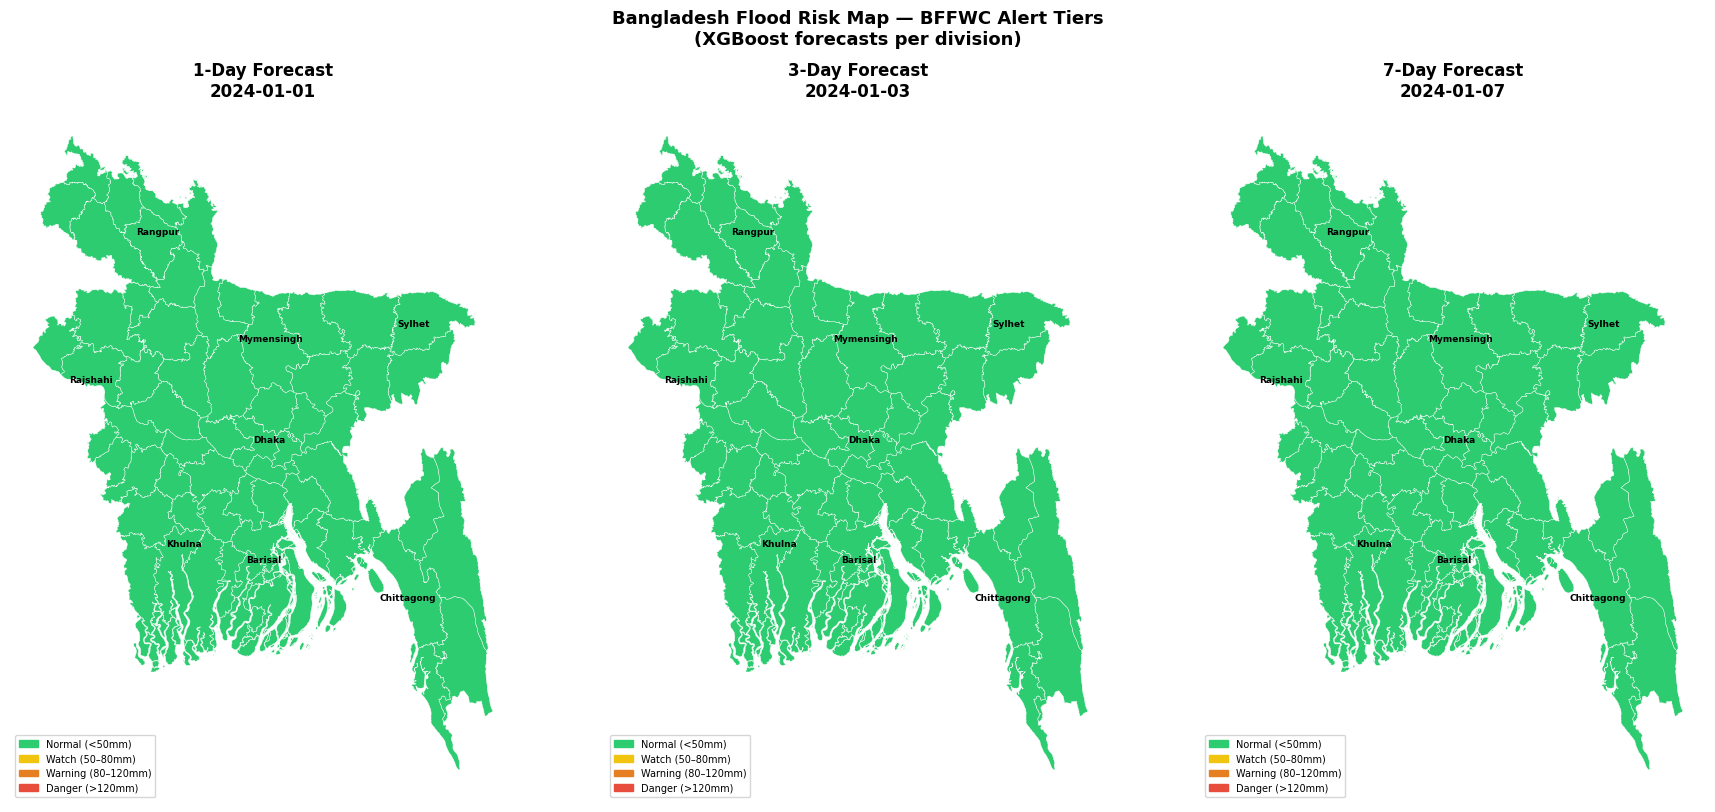

✓ Static map saved → ../data/processed/static_risk_map.png


In [11]:
# Quick static preview before building the interactive Folium map
# Useful to verify colours and geometry look correct

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, h in enumerate(HORIZONS):
    ax      = axes[i]
    gdf_h   = make_choropleth_gdf(horizon_days=h)

    # Map risk tier to a numeric score for colourmap
    tier_score = {
        "🟢 NORMAL": 0, "🟡 WATCH": 1,
        "🟠 WARNING": 2, "🔴 DANGER": 3
    }
    gdf_h["risk_score"] = gdf_h["risk_tier"].map(tier_score).fillna(0)

    gdf_h.plot(
        column     = "risk_score",
        ax         = ax,
        cmap       = mcolors.ListedColormap(
                         ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"]
                     ),
        vmin=0, vmax=3,
        edgecolor  = "white",
        linewidth  = 0.3,
        legend     = False,
    )

    # Add division labels
    for station, info in DIVISION_CENTRES.items():
        ax.annotate(
            info["label"],
            xy=(info["lon"], info["lat"]),
            ha="center", va="center",
            fontsize=6.5, fontweight="bold",
            color="black",
        )

    # Add BFFWC legend
    from matplotlib.patches import Patch
    legend_items = [
        Patch(color="#2ECC71", label="Normal (<50mm)"),
        Patch(color="#F1C40F", label="Watch (50–80mm)"),
        Patch(color="#E67E22", label="Warning (80–120mm)"),
        Patch(color="#E74C3C", label="Danger (>120mm)"),
    ]
    ax.legend(handles=legend_items, loc="lower left", fontsize=7)

    fc_date = forecast_df[forecast_df["horizon_days"] == h]["forecast_date"].iloc[0]
    ax.set_title(f"{h}-Day Forecast\n{fc_date}", fontweight="bold")
    ax.set_axis_off()

plt.suptitle("Bangladesh Flood Risk Map — BFFWC Alert Tiers\n"
             "(XGBoost forecasts per division)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/static_risk_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Static map saved → ../data/processed/static_risk_map.png")

## Build interactive Folium map — 1-day forecast

In [13]:
def build_folium_map(horizon_days=1, save_path=None):
    """
    Builds a full interactive Folium choropleth map for one horizon.

    Features:
      - Choropleth districts coloured by flood risk tier
      - Clickable district popups with forecast details
      - Division marker pins with predicted rainfall
      - Legend and title overlay
      - Fullscreen button
    """
    gdf_h = make_choropleth_gdf(horizon_days=horizon_days)
    fc    = forecast_df[forecast_df["horizon_days"] == horizon_days].copy()

    # ── FIX: Convert date objects to strings for JSON serialisation ───────
    if "forecast_date" in gdf_h.columns:
        gdf_h["forecast_date"] = gdf_h["forecast_date"].astype(str)
    if "forecast_date" in fc.columns:
        fc["forecast_date"] = fc["forecast_date"].astype(str)
    # Also stringify any other object columns that may hold date values
    for col in gdf_h.columns:
        if col == "geometry":
            continue
        if gdf_h[col].dtype == "object":
            import datetime
            gdf_h[col] = gdf_h[col].apply(
                lambda x: x.isoformat()
                if isinstance(x, (datetime.date, datetime.datetime))
                else x
            )
    # ─────────────────────────────────────────────────────────────────────

    # ── Base map ─────────────────────────────────────────────────────────
    m = folium.Map(
        location    = [BD_LAT, BD_LON],
        zoom_start  = 7,
        tiles       = "CartoDB positron",
        width       = "100%",
        height      = "100%",
    )

    # ── Choropleth layer ─────────────────────────────────────────────────
    tier_num = {"🟢 NORMAL": 0, "🟡 WATCH": 1,
                "🟠 WARNING": 2, "🔴 DANGER": 3}
    gdf_h["risk_num"] = gdf_h["risk_tier"].map(tier_num).fillna(0)

    folium.Choropleth(
        geo_data       = gdf_h.__geo_interface__,
        data           = gdf_h[["NAME_2", "risk_num"]],
        columns        = ["NAME_2", "risk_num"],
        key_on         = "feature.properties.NAME_2",
        fill_color     = "YlOrRd",
        fill_opacity   = 0.65,
        line_opacity   = 0.4,
        line_color     = "white",
        line_weight    = 0.5,
        legend_name    = f"Flood Risk Score (0=Normal → 3=Danger) — {horizon_days}-day forecast",
        nan_fill_color = "#cccccc",
        smooth_factor  = 1.0,
    ).add_to(m)

    # ── Clickable district popups ─────────────────────────────────────────
    def district_style(feature):
        tier = feature["properties"].get("risk_tier", "🟢 NORMAL")
        col  = RISK_COLOURS.get(tier, "#2ECC71")
        return {
            "fillColor":   col,
            "color":       "white",
            "weight":      0.5,
            "fillOpacity": 0.65,
        }

    def district_highlight(feature):
        return {"weight": 2.5, "color": "#333333", "fillOpacity": 0.85}

    folium.GeoJson(
        gdf_h.__geo_interface__,
        style_function     = district_style,
        highlight_function = district_highlight,
        tooltip = folium.GeoJsonTooltip(
            fields    = ["NAME_2", "NAME_1", "risk_tier", "predicted_mm"],
            aliases   = ["District:", "Division:", "Risk tier:", "Predicted rain:"],
            localize  = True,
            sticky    = False,
            style     = ("background-color: white; color: #333; "
                         "font-family: Arial; font-size: 13px; padding: 6px;"),
        ),
        popup = folium.GeoJsonPopup(
            fields    = ["NAME_2", "NAME_1", "predicted_mm", "risk_tier", "forecast_date"],
            aliases   = ["District", "Division", "Predicted rainfall (mm)",
                         "Risk tier", "Forecast date"],
            style     = "font-family: Arial; font-size: 13px;",
            max_width = 300,
        ),
    ).add_to(m)

    # ── Division marker pins ──────────────────────────────────────────────
    for _, row in fc.iterrows():
        station = row["station"]
        info    = DIVISION_CENTRES[station]
        tier    = row["risk_tier"]
        mm      = row["predicted_mm"]
        colour  = RISK_COLOURS.get(tier, "#2ECC71")

        icon_colour = {
            "🟢 NORMAL":  "green",
            "🟡 WATCH":   "orange",
            "🟠 WARNING": "red",
            "🔴 DANGER":  "darkred",
        }.get(tier, "green")

        popup_html = f"""
        <div style="font-family:Arial; font-size:13px; width:220px;">
          <b style="font-size:15px;">{info['label']}</b><br>
          <hr style="margin:6px 0;">
          <b>Forecast date:</b> {row['forecast_date']}<br>
          <b>Predicted:</b> {mm:.1f} mm/day<br>
          <b>Risk tier:</b> <span style="color:{colour}; font-weight:bold;">
            {tier}</span><br>
          <hr style="margin:6px 0;">
          <b>Thresholds:</b><br>
          &nbsp;🟡 Watch   : &gt;50 mm<br>
          &nbsp;🟠 Warning : &gt;80 mm<br>
          &nbsp;🔴 Danger  : &gt;120 mm
        </div>
        """
        folium.Marker(
            location = [info["lat"], info["lon"]],
            popup    = folium.Popup(popup_html, max_width=260),
            tooltip  = f"{info['label']} — {mm:.1f} mm ({tier})",
            icon     = folium.Icon(color=icon_colour, icon="tint", prefix="fa"),
        ).add_to(m)

    # ── HTML legend overlay ───────────────────────────────────────────────
    legend_html = f"""
    <div style="
        position: fixed; bottom: 40px; left: 40px; z-index: 1000;
        background-color: white; border: 2px solid #aaa;
        border-radius: 8px; padding: 12px 16px;
        font-family: Arial; font-size: 13px;
        box-shadow: 3px 3px 8px rgba(0,0,0,0.2);
    ">
      <b style="font-size:14px;">🌊 Flood Risk Legend</b>
      <hr style="margin:6px 0;">
      <div style="margin:4px 0;">
        <span style="background:#2ECC71;padding:2px 8px;border-radius:3px;">&nbsp;</span>
        &nbsp;🟢 Normal  (&lt;50 mm)
      </div>
      <div style="margin:4px 0;">
        <span style="background:#F1C40F;padding:2px 8px;border-radius:3px;">&nbsp;</span>
        &nbsp;🟡 Watch   (50–80 mm)
      </div>
      <div style="margin:4px 0;">
        <span style="background:#E67E22;padding:2px 8px;border-radius:3px;">&nbsp;</span>
        &nbsp;🟠 Warning (80–120 mm)
      </div>
      <div style="margin:4px 0;">
        <span style="background:#E74C3C;padding:2px 8px;border-radius:3px;">&nbsp;</span>
        &nbsp;🔴 Danger  (&gt;120 mm)
      </div>
      <hr style="margin:6px 0;">
      <small>Source: XGBoost model | NASA POWER data<br>
      BFFWC alert thresholds | {horizon_days}-day forecast</small>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    # ── Title overlay ─────────────────────────────────────────────────────
    fc_date = fc["forecast_date"].iloc[0] if len(fc) > 0 else "N/A"
    title_html = f"""
    <div style="
        position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
        z-index: 1000; background-color: white;
        border: 2px solid #aaa; border-radius: 8px;
        padding: 8px 20px; font-family: Arial;
        box-shadow: 3px 3px 8px rgba(0,0,0,0.2);
        text-align: center;
    ">
      <b style="font-size:15px;">🇧🇩 Bangladesh Flood Risk Forecast</b><br>
      <span style="font-size:12px; color:#555;">
        {horizon_days}-day ahead &nbsp;|&nbsp; Forecast date: {fc_date}
      </span>
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    # ── Fullscreen button ─────────────────────────────────────────────────
    plugins.Fullscreen(position="topright").add_to(m)

    # ── Layer control ─────────────────────────────────────────────────────
    folium.LayerControl().add_to(m)

    # ── Save ──────────────────────────────────────────────────────────────
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)  # FIX: ensure dir exists
        m.save(save_path)
        print(f"✓ Saved → {save_path}")

    return m


# Build and display 1-day map inline in notebook
print("Building 1-day forecast map...")
map_1d = build_folium_map(
    horizon_days = 1,
    save_path    = "../data/processed/flood_risk_map_1d.html"
)
map_1d   # renders inline in Jupyter

Building 1-day forecast map...
✓ Saved → ../data/processed/flood_risk_map_1d.html


## Build 3-day and 7-day maps

In [14]:
print("Building 3-day forecast map...")
map_3d = build_folium_map(
    horizon_days = 3,
    save_path    = "../data/processed/flood_risk_map_3d.html"
)

print("Building 7-day forecast map...")
map_7d = build_folium_map(
    horizon_days = 7,
    save_path    = "../data/processed/flood_risk_map_7d.html"
)

print("\n✓ All three horizon maps saved:")
print("  ../data/processed/flood_risk_map_1d.html")
print("  ../data/processed/flood_risk_map_3d.html")
print("  ../data/processed/flood_risk_map_7d.html")
print("\nOpen any .html file in your browser to view the interactive map")

Building 3-day forecast map...
✓ Saved → ../data/processed/flood_risk_map_3d.html
Building 7-day forecast map...
✓ Saved → ../data/processed/flood_risk_map_7d.html

✓ All three horizon maps saved:
  ../data/processed/flood_risk_map_1d.html
  ../data/processed/flood_risk_map_3d.html
  ../data/processed/flood_risk_map_7d.html

Open any .html file in your browser to view the interactive map


## Historical flood frequency map

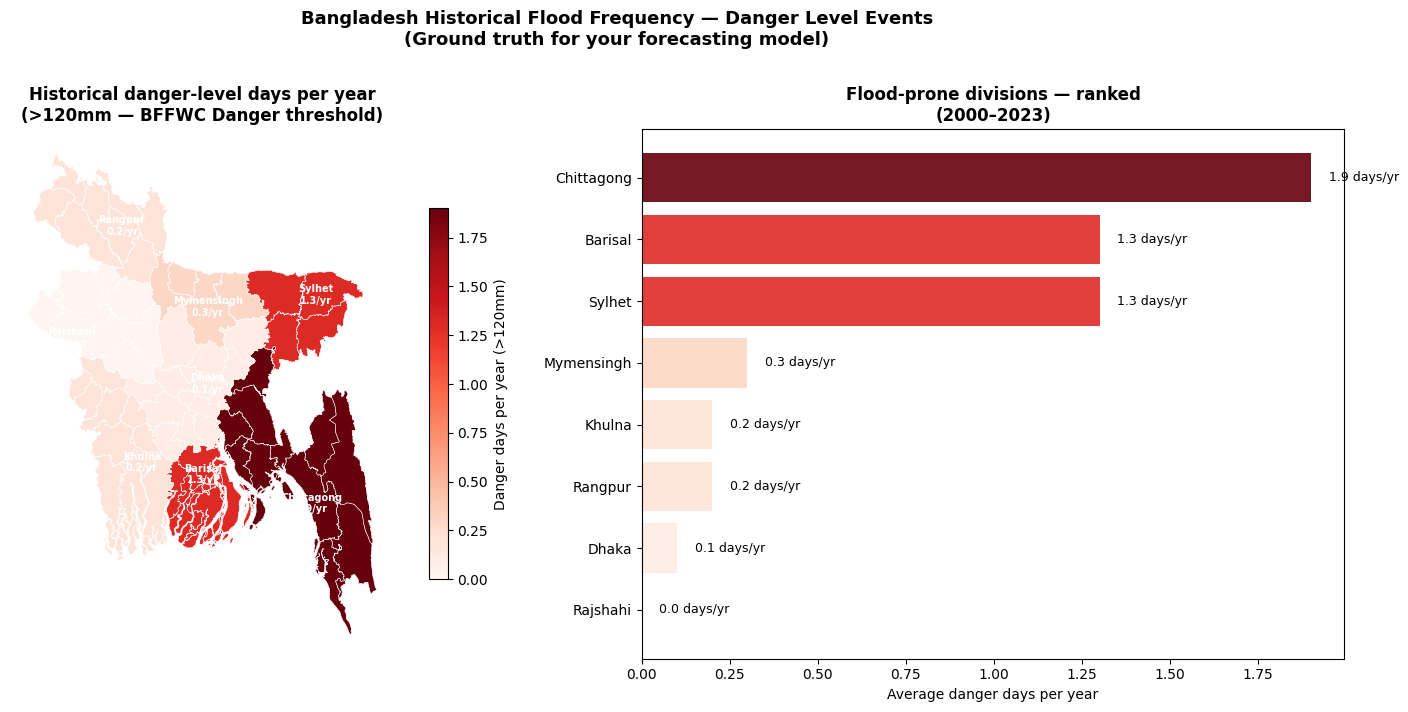


Historical summary:


,station,danger_days,danger_days_yr,max_rain,pct_danger
0,chittagong,46,1.9,395.8,0.525
1,sylhet,32,1.3,279.9,0.365
2,barisal,31,1.3,272.1,0.354
3,mymensingh,8,0.3,171.7,0.091
4,khulna,5,0.2,244.3,0.057
5,rangpur,6,0.2,160.0,0.068
6,dhaka,3,0.1,167.3,0.034
7,rajshahi,0,0.0,98.1,0.000


In [15]:
# Show historically how often each division exceeded danger threshold
# This is the ground truth context behind your forecasts

freq_records = []

for station, df in all_data.items():
    rain        = df["rainfall_mm"]
    total_days  = len(rain)
    years       = (df.index.max() - df.index.min()).days / 365

    freq_records.append({
        "station":          station,
        "division_key":     station,
        "danger_days":      int((rain > 120).sum()),
        "warning_days":     int((rain > 80).sum()),
        "watch_days":       int((rain > 50).sum()),
        "danger_days_yr":   round((rain > 120).sum() / years, 1),
        "max_rain":         round(rain.max(), 1),
        "pct_danger":       round((rain > 120).mean() * 100, 3),
    })

freq_df = pd.DataFrame(freq_records)

# Merge into GeoDataFrame
gdf_freq = gdf.merge(freq_df, on="division_key", how="left")
gdf_freq["danger_days_yr"] = gdf_freq["danger_days_yr"].fillna(0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — danger days per year choropleth
ax = axes[0]
gdf_freq.plot(
    column    = "danger_days_yr",
    ax        = ax,
    cmap      = "Reds",
    edgecolor = "white",
    linewidth = 0.4,
    legend    = True,
    legend_kwds = {"label": "Danger days per year (>120mm)", "shrink": 0.7},
)
for station, info in DIVISION_CENTRES.items():
    row = freq_df[freq_df["station"] == station]
    if len(row) > 0:
        ax.annotate(
            f"{info['label']}\n{row['danger_days_yr'].values[0]:.1f}/yr",
            xy=(info["lon"], info["lat"]),
            ha="center", va="center",
            fontsize=7, fontweight="bold", color="white",
        )
ax.set_title("Historical danger-level days per year\n(>120mm — BFFWC Danger threshold)",
             fontweight="bold")
ax.set_axis_off()

# Right — bar chart
ax = axes[1]
freq_sorted = freq_df.sort_values("danger_days_yr", ascending=True)
colours = plt.cm.Reds(
    [v / freq_df["danger_days_yr"].max() for v in freq_sorted["danger_days_yr"]]
)
bars = ax.barh(freq_sorted["station"].str.title(),
               freq_sorted["danger_days_yr"],
               color=colours, alpha=0.9)
for bar, val in zip(bars, freq_sorted["danger_days_yr"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} days/yr",
            va="center", fontsize=9)
ax.set_xlabel("Average danger days per year")
ax.set_title("Flood-prone divisions — ranked\n(2000–2023)",
             fontweight="bold")

plt.suptitle("Bangladesh Historical Flood Frequency — Danger Level Events\n"
             "(Ground truth for your forecasting model)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/historical_flood_frequency.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nHistorical summary:")
display(freq_df.sort_values("danger_days_yr", ascending=False)
        [["station","danger_days","danger_days_yr","max_rain","pct_danger"]]
        .reset_index(drop=True))

## Build multi-tab HTML report

In [20]:
# Combine all 3 horizon maps into a single HTML file with tab navigation
# This is what you share as your project demo link

# Read each saved map's HTML content directly
def read_map_html(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

map_1d_html = read_map_html("../data/processed/flood_risk_map_1d.html")
map_3d_html = read_map_html("../data/processed/flood_risk_map_3d.html")
map_7d_html = read_map_html("../data/processed/flood_risk_map_7d.html")

# Build HTML using .format() or concatenation — safer than f-string for large HTML
html_template = """<!DOCTYPE html>
<html>
<head>
  <meta charset="UTF-8">
  <title>Bangladesh Flood Risk Dashboard</title>
  <style>
    body { font-family: Arial; margin: 0; padding: 10px; }
    .tab { display: none; }
    .tab.active { display: block; }
    .tab-buttons button {
      padding: 8px 20px; margin-right: 4px;
      cursor: pointer; border: 1px solid #aaa;
      background: #f0f0f0; border-radius: 4px;
    }
    .tab-buttons button.active {
      background: #2c7bb6; color: white; border-color: #2c7bb6;
    }
  </style>
</head>
<body>
  <p>XGBoost multi-step model | NASA POWER data | BFFWC alert thresholds</p>
  <p>Normal (&lt;50mm) | Watch (50-80mm) | Warning (80-120mm) | Danger (&gt;120mm)</p>

  <div class="tab-buttons">
    <button class="active" onclick="showTab(0)">1-Day Forecast</button>
    <button onclick="showTab(1)">3-Day Forecast</button>
    <button onclick="showTab(2)">7-Day Forecast</button>
  </div>

  <div id="tab0" class="tab active">MAP_1D</div>
  <div id="tab1" class="tab">MAP_3D</div>
  <div id="tab2" class="tab">MAP_7D</div>

  <script>
    function showTab(n) {
      document.querySelectorAll('.tab').forEach(function(t, i) {
        t.classList.toggle('active', i === n);
      });
      document.querySelectorAll('.tab-buttons button').forEach(function(b, i) {
        b.classList.toggle('active', i === n);
      });
    }
  </script>
</body>
</html>"""

# Inject map HTML via replace — avoids all f-string / escaping issues
html_template = html_template.replace("MAP_1D", map_1d_html)
html_template = html_template.replace("MAP_3D", map_3d_html)
html_template = html_template.replace("MAP_7D", map_7d_html)

report_path = "../data/processed/flood_dashboard.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"✓ Dashboard saved → {report_path}")
print("\nTo view:")
print("  Open ../data/processed/flood_dashboard.html in your browser")
print("  All 3 maps must be in the same folder for iframes to load")

✓ Dashboard saved → ../data/processed/flood_dashboard.html

To view:
  Open ../data/processed/flood_dashboard.html in your browser
  All 3 maps must be in the same folder for iframes to load
